In [1]:
import pyccl as ccl
ccl.__version__
import numpy as np
import matplotlib as mpl
import matplotlib.pylab as plt

cmap = plt.cm.magma

x = np.arange(0,3072)

In [2]:
oc = np.linspace(.1, .9, 50)
ob = np.linspace(.03, .7, 50)
h = np.linspace(.55, .91, 50)
As = np.linspace(1.89e-9,2.5e-9,50)
ns = np.linspace(.87, 1.07, 50)
#ok = np.linspace() #not varying?
w0 = np.linspace(-3, -1, 50)
wa = np.linspace(-3, 1, 50)

In [3]:
pz_path = '/home/s1/ggibbins/practice/lsst_like_dndz/' #where you saved the files from google drive

cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0, w0 = -1, wa= 0.0, extra_parameters={"camb": {"dark_energy_model": "ppf"}})

nside = 1024
ell = np.arange(0,  3*nside+1)
bias_z = [1.0, 1.1, 1.2, 1.5, 2.0]

In [4]:
galtracers_dndz = []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_lensgalaxies_bin_'+str(i)+'.npy')
    galtracers_dndz.append(nz)

galtracers_dndz = np.array(galtracers_dndz)

wltracers_dndz = []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_sourcegalaxies_bin_'+str(i)+'.npy')
    wltracers_dndz.append(nz)

wltracers_dndz = np.array(wltracers_dndz)

In [5]:
cmap = plt.cm.copper

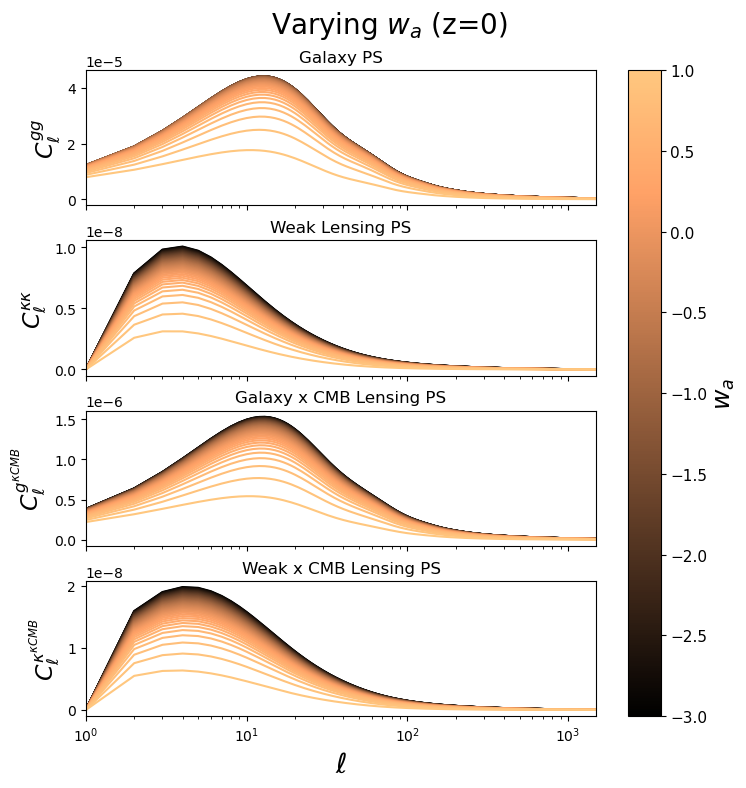

In [6]:
#Vary wa with sub plots of diff probes

#Z ==== 0

fig, axs = plt.subplots(4,sharex=True, figsize=(7,8)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Varying $w_{a}$ (z=0)", fontsize=20)

norm = mpl.colors.Normalize(vmin = wa[0], vmax = wa[49])

#Gal Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[0]), bias= (zz,  bias_z[0]*np.ones(len(zz))))
    gal_auto = ccl.angular_cl(cosmo, gal, gal, ell)
    axs[0].plot(ell, gal_auto, c = cmap(norm(wa[c])))

#WL Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[0]))
    lens_auto = ccl.angular_cl(cosmo, lens, lens, ell)
    axs[1].plot(ell, lens_auto, c = cmap(norm(wa[c])))

#Gal x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[0]), bias= (zz,  bias_z[0]*np.ones(len(zz))))
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    gal_cmb = ccl.angular_cl(cosmo, gal, cmb_lensing, ell)
    axs[2].plot(ell, gal_cmb, c = cmap(norm(wa[c])))
    
#WL x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[0]))
    lens_cmb = ccl.angular_cl(cosmo, lens, cmb_lensing, ell)
    axs[3].plot(ell, lens_cmb, c = cmap(norm(wa[c])))

plt.xscale('log')
plt.xlim(1,1500)
plt.xlabel(r'$\ell$', fontsize=20)
fig.tight_layout()

axs[0].set_ylabel(r'$C_{\ell}^{gg}$', fontsize=17)
axs[0].set_title("Galaxy PS")

axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$', fontsize=17)
axs[1].set_title("Weak Lensing PS")

axs[2].set_ylabel(r'$C_{\ell}^{g^{{\kappa}CMB}}$', fontsize=17)
axs[2].set_title("Galaxy x CMB Lensing PS")

axs[3].set_ylabel(r'$C_{\ell}^{\kappa^{{\kappa}CMB}}$', fontsize=17)
axs[3].set_title("Weak x CMB Lensing PS")
                 
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax = fig.get_axes())
cb.ax.tick_params(labelsize=11)
cb.set_label(label = '$w_{a}$', size = 18)

In [7]:
cmap = plt.cm.cool

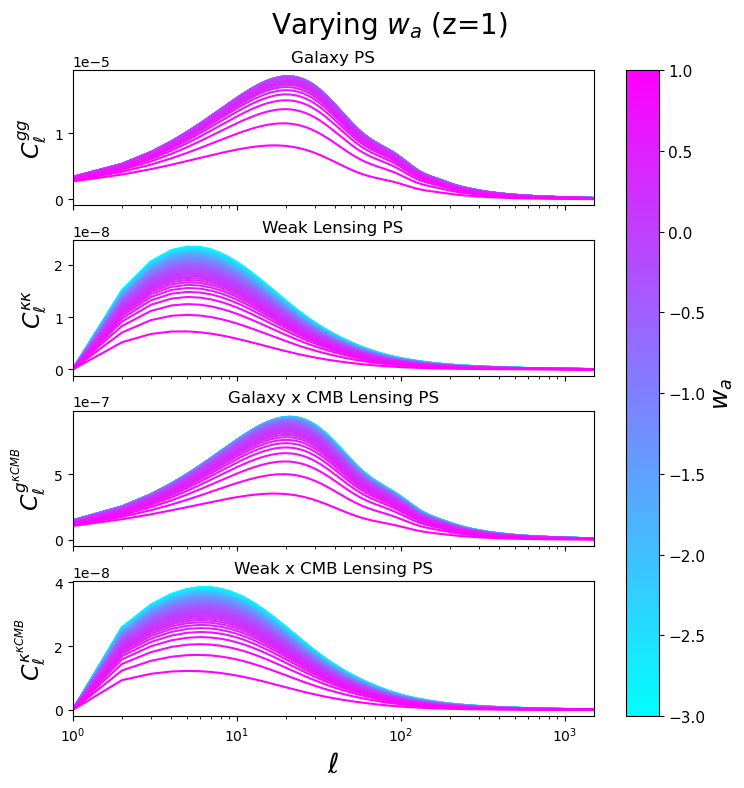

In [8]:
#Vary wa with sub plots of diff probes

#Z ==== 1

fig, axs = plt.subplots(4,sharex=True, figsize=(7,8)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Varying $w_{a}$ (z=1)", fontsize=20)

norm = mpl.colors.Normalize(vmin = wa[0], vmax = wa[49])

#Gal Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[1]), bias= (zz,  bias_z[1]*np.ones(len(zz))))
    gal_auto = ccl.angular_cl(cosmo, gal, gal, ell)
    axs[0].plot(ell, gal_auto, c = cmap(norm(wa[c])))

#WL Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[1]))
    lens_auto = ccl.angular_cl(cosmo, lens, lens, ell)
    axs[1].plot(ell, lens_auto, c = cmap(norm(wa[c])))

#Gal x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[1]), bias= (zz,  bias_z[1]*np.ones(len(zz))))
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    gal_cmb = ccl.angular_cl(cosmo, gal, cmb_lensing, ell)
    axs[2].plot(ell, gal_cmb, c = cmap(norm(wa[c])))
    
#WL x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[1]))
    lens_cmb = ccl.angular_cl(cosmo, lens, cmb_lensing, ell)
    axs[3].plot(ell, lens_cmb, c = cmap(norm(wa[c])))

plt.xscale('log')
plt.xlim(1,1500)
plt.xlabel(r'$\ell$', fontsize=20)
fig.tight_layout()

axs[0].set_ylabel(r'$C_{\ell}^{gg}$', fontsize=17)
axs[0].set_title("Galaxy PS")

axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$', fontsize=17)
axs[1].set_title("Weak Lensing PS")

axs[2].set_ylabel(r'$C_{\ell}^{g^{{\kappa}CMB}}$', fontsize=17)
axs[2].set_title("Galaxy x CMB Lensing PS")

axs[3].set_ylabel(r'$C_{\ell}^{\kappa^{{\kappa}CMB}}$', fontsize=17)
axs[3].set_title("Weak x CMB Lensing PS")
                 
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax = fig.get_axes())
cb.ax.tick_params(labelsize=11)
cb.set_label(label = '$w_{a}$', size = 18)

In [9]:
cmap = plt.cm.coolwarm

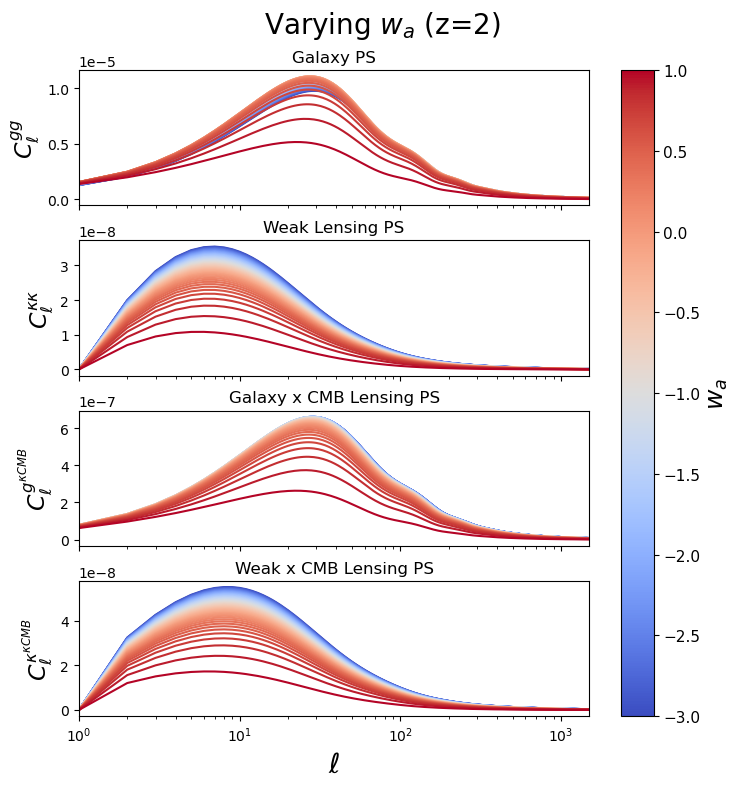

In [10]:
#Vary wa with sub plots of diff probes

#Z ==== 2

fig, axs = plt.subplots(4,sharex=True, figsize=(7,8)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Varying $w_{a}$ (z=2)", fontsize=20)

norm = mpl.colors.Normalize(vmin = wa[0], vmax = wa[49])

#Gal Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[2]), bias= (zz,  bias_z[2]*np.ones(len(zz))))
    gal_auto = ccl.angular_cl(cosmo, gal, gal, ell)
    axs[0].plot(ell, gal_auto, c = cmap(norm(wa[c])))

#WL Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[2]))
    lens_auto = ccl.angular_cl(cosmo, lens, lens, ell)
    axs[1].plot(ell, lens_auto, c = cmap(norm(wa[c])))

#Gal x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[2]), bias= (zz,  bias_z[2]*np.ones(len(zz))))
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    gal_cmb = ccl.angular_cl(cosmo, gal, cmb_lensing, ell)
    axs[2].plot(ell, gal_cmb, c = cmap(norm(wa[c])))
    
#WL x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[2]))
    lens_cmb = ccl.angular_cl(cosmo, lens, cmb_lensing, ell)
    axs[3].plot(ell, lens_cmb, c = cmap(norm(wa[c])))

plt.xscale('log')
plt.xlim(1,1500)
plt.xlabel(r'$\ell$', fontsize=20)
fig.tight_layout()

axs[0].set_ylabel(r'$C_{\ell}^{gg}$', fontsize=17)
axs[0].set_title("Galaxy PS")

axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$', fontsize=17)
axs[1].set_title("Weak Lensing PS")

axs[2].set_ylabel(r'$C_{\ell}^{g^{{\kappa}CMB}}$', fontsize=17)
axs[2].set_title("Galaxy x CMB Lensing PS")

axs[3].set_ylabel(r'$C_{\ell}^{\kappa^{{\kappa}CMB}}$', fontsize=17)
axs[3].set_title("Weak x CMB Lensing PS")
                 
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax = fig.get_axes())
cb.ax.tick_params(labelsize=11)
cb.set_label(label = '$w_{a}$', size = 18)

In [11]:
cmap = plt.cm.PRGn

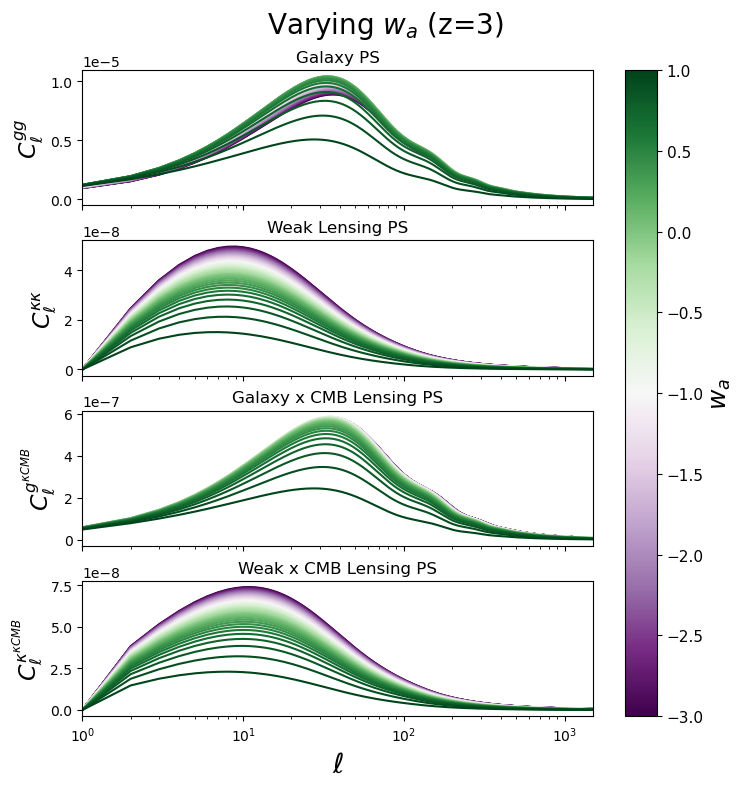

In [12]:
#Vary wa with sub plots of diff probes

#Z ==== 3

fig, axs = plt.subplots(4,sharex=True, figsize=(7,8)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Varying $w_{a}$ (z=3)", fontsize=20)

norm = mpl.colors.Normalize(vmin = wa[0], vmax = wa[49])

#Gal Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[3]), bias= (zz,  bias_z[3]*np.ones(len(zz))))
    gal_auto = ccl.angular_cl(cosmo, gal, gal, ell)
    axs[0].plot(ell, gal_auto, c = cmap(norm(wa[c])))

#WL Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[3]))
    lens_auto = ccl.angular_cl(cosmo, lens, lens, ell)
    axs[1].plot(ell, lens_auto, c = cmap(norm(wa[c])))

#Gal x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[3]), bias= (zz,  bias_z[3]*np.ones(len(zz))))
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    gal_cmb = ccl.angular_cl(cosmo, gal, cmb_lensing, ell)
    axs[2].plot(ell, gal_cmb, c = cmap(norm(wa[c])))
    
#WL x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[3]))
    lens_cmb = ccl.angular_cl(cosmo, lens, cmb_lensing, ell)
    axs[3].plot(ell, lens_cmb, c = cmap(norm(wa[c])))

plt.xscale('log')
plt.xlim(1,1500)
plt.xlabel(r'$\ell$', fontsize=20)
fig.tight_layout()

axs[0].set_ylabel(r'$C_{\ell}^{gg}$', fontsize=17)
axs[0].set_title("Galaxy PS")

axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$', fontsize=17)
axs[1].set_title("Weak Lensing PS")

axs[2].set_ylabel(r'$C_{\ell}^{g^{{\kappa}CMB}}$', fontsize=17)
axs[2].set_title("Galaxy x CMB Lensing PS")

axs[3].set_ylabel(r'$C_{\ell}^{\kappa^{{\kappa}CMB}}$', fontsize=17)
axs[3].set_title("Weak x CMB Lensing PS")
                 
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax = fig.get_axes())
cb.ax.tick_params(labelsize=11)
cb.set_label(label = '$w_{a}$', size = 18)

In [13]:
cmap = plt.cm.PuOr

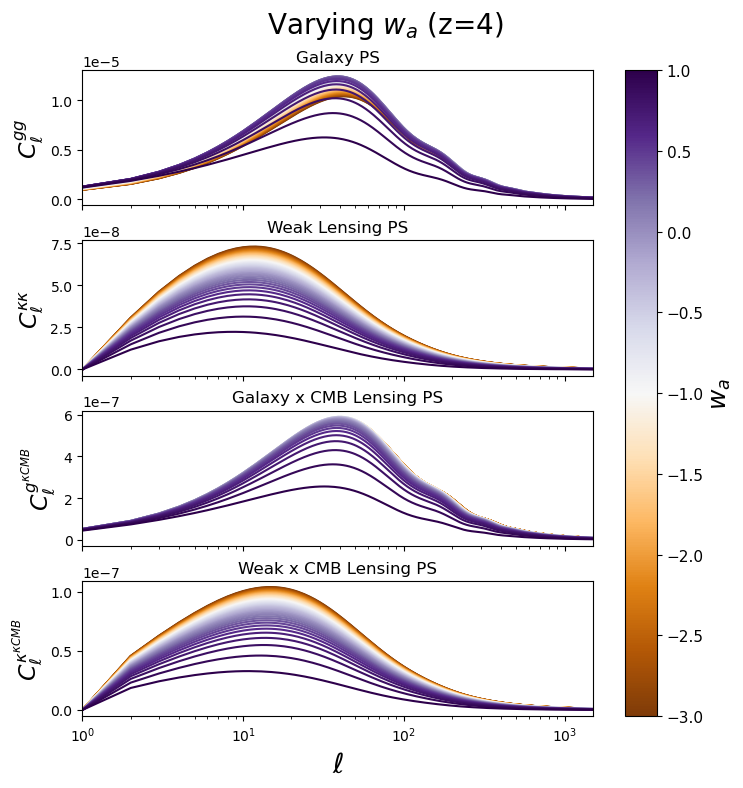

In [14]:
#Vary wa with sub plots of diff probes

#Z ==== 4

fig, axs = plt.subplots(4,sharex=True, figsize=(7,8)) #sharey=false to see differences in more detail (true shows scale better)

fig.suptitle("Varying $w_{a}$ (z=4)", fontsize=20)

norm = mpl.colors.Normalize(vmin = wa[0], vmax = wa[49])

#Gal Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[4]), bias= (zz,  bias_z[4]*np.ones(len(zz))))
    gal_auto = ccl.angular_cl(cosmo, gal, gal, ell)
    axs[0].plot(ell, gal_auto, c = cmap(norm(wa[c])))

#WL Auto: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[4]))
    lens_auto = ccl.angular_cl(cosmo, lens, lens, ell)
    axs[1].plot(ell, lens_auto, c = cmap(norm(wa[c])))

#Gal x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[4]), bias= (zz,  bias_z[4]*np.ones(len(zz))))
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    gal_cmb = ccl.angular_cl(cosmo, gal, cmb_lensing, ell)
    axs[2].plot(ell, gal_cmb, c = cmap(norm(wa[c])))
    
#WL x CMB: Iterates through wa list to create a cross ps for each value
for c in range(50): #iterates thru cosmologies
    cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, 
        h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0,
        w0 = -1, wa= wa[c], extra_parameters={"camb": {"dark_energy_model": "ppf"}}) #Creates 50 cosmologies varying wa from -3 to 1
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[4]))
    lens_cmb = ccl.angular_cl(cosmo, lens, cmb_lensing, ell)
    axs[3].plot(ell, lens_cmb, c = cmap(norm(wa[c])))

plt.xscale('log')
plt.xlim(1,1500)
plt.xlabel(r'$\ell$', fontsize=20)
fig.tight_layout()

axs[0].set_ylabel(r'$C_{\ell}^{gg}$', fontsize=17)
axs[0].set_title("Galaxy PS")

axs[1].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$', fontsize=17)
axs[1].set_title("Weak Lensing PS")

axs[2].set_ylabel(r'$C_{\ell}^{g^{{\kappa}CMB}}$', fontsize=17)
axs[2].set_title("Galaxy x CMB Lensing PS")

axs[3].set_ylabel(r'$C_{\ell}^{\kappa^{{\kappa}CMB}}$', fontsize=17)
axs[3].set_title("Weak x CMB Lensing PS")
                 
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax = fig.get_axes())
cb.ax.tick_params(labelsize=11)
cb.set_label(label = '$w_{a}$', size = 18)

In [ ]:
#Corner plot of parameters comparing probes